In [1]:
import pandas as pd

In [2]:
GEOMETRY_FILE1 = "/groups/pheno/inar/orca_prometheus/orca_sensor_geometry.csv"
sensor_geometry_df_orca = pd.read_csv(GEOMETRY_FILE1, index_col='sensor_id')

from polarbert.pretraining import get_dataloaders
from polarbert.config import PolarBertConfig

config_file = "/groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml"
config = PolarBertConfig.from_yaml(config_file)

config_dict = config.to_dict()
config_dict["training"]["per_device_batch_size"] = 32

config_p = config_dict.copy()
config_p["data"]["val_events"] = 1000
config_p["data"]["train_dir"] = "/groups/pheno/inar/orca_prometheus/memmaped_orca"
del config_p["data"]["val_dir"]
train_loader_p, val_loader_p = get_dataloaders(config_p, dataset_type='prometheus')



Loading configuration from: /groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml
Validating configuration...
Configuration validation passed (with potential warnings).


/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:154: UserWarning: In ModelConfig: Unexpected keys found in config dictionary and will be ignored: {'dom_embed_dim'}
  warnings.warn(
/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:457: UserWarning: training.final_div_factor (0.133333) < 1.0. Usually >= 1.0 (e.g., 1e4) for OneCycleLR.
  warnings.warn(f"training.final_div_factor ({train_cfg.final_div_factor}) < 1.0. "


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import math
from pathlib import Path
import pyarrow.parquet as pq # For reading parquet
# import pyarrow.compute as pc # Top-level import is good, but we'll add it locally too for robustness
from scipy.spatial import cKDTree # For SensorMapping
from typing import Optional, Tuple, List, Dict, Any

# --- SensorMapping Class (as provided by you) ---
class SensorMapping:
    """
    Handles mapping of pulse coordinates to sensor IDs using a geometry file.
    Uses a KD-tree for efficient nearest neighbor search.
    """
    def __init__(self, geometry_file: str):
        print(f"SensorMapping: Loading geometry from {geometry_file}")
        try:
            self.sensor_geometry = pd.read_csv(geometry_file)
        except Exception as e:
            raise FileNotFoundError(f"Could not read geometry file: {geometry_file}. Error: {e}")

        if not {'x', 'y', 'z'}.issubset(self.sensor_geometry.columns):
            raise ValueError("Geometry CSV must contain 'x', 'y', 'z' columns.")

        self.geometry_coords = self.sensor_geometry[['x', 'y', 'z']].values
        
        if 'sensor_id' in self.sensor_geometry.columns:
            self.sensor_ids_map = self.sensor_geometry['sensor_id'].values
            print("SensorMapping: Using 'sensor_id' column from geometry file for mapping.")
        else:
            # If no explicit sensor_id column, assume 0-indexed row number is the ID
            self.sensor_ids_map = self.sensor_geometry.index.values
            print("SensorMapping: Using row index from geometry file as 'sensor_id' for mapping.")

        self.kdtree = None 
        self.z_offset = 0.0 
        print(f"SensorMapping: Loaded {len(self.geometry_coords)} sensor positions.")
        
    def calculate_z_offset(self, data_file_path: str) -> float:
        import pyarrow.compute as pc # Local import for robustness
        print(f"SensorMapping: Calculating Z-offset using pulse data from: {data_file_path}")
        try:
            sample_data = pq.read_table(data_file_path, columns=['sensor_pos_z'])
            data_z = sample_data['sensor_pos_z'].to_numpy()
            if len(data_z) == 0:
                print("SensorMapping: Warning - No 'sensor_pos_z' data in the sample file for Z-offset calibration.")
                return 0.0
            
            z_prom_min, z_prom_max = np.min(data_z), np.max(data_z)
            z_prom_center = (z_prom_max + z_prom_min) / 2
            
            geom_z_min, geom_z_max = np.min(self.geometry_coords[:,2]), np.max(self.geometry_coords[:,2])
            z_geom_center = (geom_z_max + geom_z_min) / 2
            
            calculated_offset = z_prom_center - z_geom_center
            print(f"SensorMapping: Pulse data Z center: {z_prom_center:.2f}, Geometry Z center: {z_geom_center:.2f}, Calculated Z-offset: {calculated_offset:.2f}")
            return calculated_offset
        except Exception as e:
            print(f"SensorMapping: Warning - Error during Z-offset calculation: {e}. Using Z-offset of 0.")
            return 0.0
    
    def initialize_mapping(self, pulse_data_file_path: Optional[str] = None, apply_z_offset_calibration: bool = False) -> None:
        if apply_z_offset_calibration and pulse_data_file_path is not None:
            self.z_offset = self.calculate_z_offset(pulse_data_file_path)
        else:
            self.z_offset = 0.0
            if apply_z_offset_calibration:
                 print("SensorMapping: No pulse data file provided for Z-offset calibration, or calibration disabled. Using Z-offset of 0.")
            else:
                 print("SensorMapping: Z-offset calibration disabled. Using Z-offset of 0.")
            
        adjusted_geom_coords = self.geometry_coords.copy()
        adjusted_geom_coords[:, 2] -= self.z_offset 

        self.kdtree = cKDTree(adjusted_geom_coords)
        print(f"SensorMapping: Initialized KD-tree with {len(adjusted_geom_coords)} sensors. Applied Z-offset to KDTree geometry: {self.z_offset:.2f} meters.")
    
    def coords_to_sensor_ids(self, coords: np.ndarray) -> np.ndarray:
        if self.kdtree is None:
            print("SensorMapping: Warning - KD-tree not initialized. Initializing now without Z-offset calibration from pulse data.")
            self.initialize_mapping(pulse_data_file_path=None, apply_z_offset_calibration=False)
            
        distances, indices_in_geometry = self.kdtree.query(coords, k=1)
        mapped_sensor_ids = self.sensor_ids_map[indices_in_geometry]
        return mapped_sensor_ids

# --- Data Loading and Processing Functions ---
def load_event_from_parquet(event_no_to_load: int,
                            pulse_file_path: str,
                            truth_file_path: str,
                            labels_to_extract: List[str] = ['initial_state_azimuth', 'initial_state_zenith']
                           ) -> Tuple[Optional[pd.DataFrame], Optional[Dict[str, Any]]]:
    """
    Loads pulse data and truth data for a specific event_no from Parquet files.
    """
    import pyarrow.compute as pc # Ensure pc is defined in this function's scope
    print(f"Loading event {event_no_to_load} from Parquet files...")
    try:
        pulse_table = pq.read_table(pulse_file_path)
        event_pulses_df = pulse_table.filter(pc.equal(pulse_table['event_no'], event_no_to_load)).to_pandas()
        if event_pulses_df.empty:
            print(f"Event {event_no_to_load} not found in pulse file: {pulse_file_path}")
            return None, None
    except Exception as e:
        print(f"Error reading pulse file {pulse_file_path}: {e}")
        return None, None

    truth_data = None
    try:
        truth_table = pq.read_table(truth_file_path, columns=['event_no'] + labels_to_extract)
        event_truth_df = truth_table.filter(pc.equal(truth_table['event_no'], event_no_to_load)).to_pandas()
        if not event_truth_df.empty:
            truth_data = event_truth_df.iloc[0].to_dict()
        else:
            print(f"Event {event_no_to_load} not found in truth file: {truth_file_path}")
    except Exception as e:
        print(f"Error reading truth file {truth_file_path} or extracting labels: {e}")

    print(f"Loaded {len(event_pulses_df)} pulses for event {event_no_to_load}.")
    return event_pulses_df, truth_data

def process_event_for_display_from_raw(event_pulses_df: pd.DataFrame,
                                       sensor_mapper: SensorMapping,
                                       sensor_geometry_df: pd.DataFrame):
    """
    Processes raw pulse data for a single event to get per-sensor info for plotting.
    Args:
        event_pulses_df (pd.DataFrame): DataFrame of pulses for one event.
                                        Must contain 'sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z',
                                        't' (time), 'charge', 'is_signal'.
        sensor_mapper (SensorMapping): Initialized SensorMapping object.
        sensor_geometry_df (pd.DataFrame): Geometry DataFrame, indexed by 0-indexed sensor_id, with 'x','y','z'.
    Returns:
        tuple: (hit_data_aux_false, hit_data_aux_true)
    """
    if event_pulses_df.empty:
        return [], []

    # Get pulse coordinates
    pulse_coords = event_pulses_df[['sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z']].values
    
    # Map raw coordinates to sensor IDs
    sensor_ids_0idx = sensor_mapper.coords_to_sensor_ids(pulse_coords)
    
    processed_pulses_df = pd.DataFrame({
        'sensor_id': sensor_ids_0idx, 
        'time': event_pulses_df['t'],
        'charge': event_pulses_df['charge'],
        'is_aux_true': (1 - event_pulses_df['is_signal']).astype(bool) 
    })

    if sensor_geometry_df.index.name != 'sensor_id':
         raise ValueError("sensor_geometry_df must be indexed by 'sensor_id' for joining.")
    
    processed_pulses_df = processed_pulses_df.join(sensor_geometry_df[['x', 'y', 'z']], on='sensor_id')

    hit_data_aux_false = []
    hit_data_aux_true = []

    for aux_status, data_list in [(False, hit_data_aux_false), (True, hit_data_aux_true)]:
        subset_df = processed_pulses_df[processed_pulses_df['is_aux_true'] == aux_status]
        if subset_df.empty:
            continue

        grouped = subset_df.groupby('sensor_id').agg(
            first_time=('time', 'min'),
            total_charge=('charge', 'sum'),
            x=('x', 'first'), 
            y=('y', 'first'),
            z=('z', 'first')
        ).dropna(subset=['x','y','z'])

        for sensor_id, row in grouped.iterrows():
            data_list.append({
                'coords': (row['x'], row['y'], row['z']),
                'first_time': row['first_time'],
                'total_charge': row['total_charge']
            })
            
    return hit_data_aux_false, hit_data_aux_true

# --- Plotting Function (with larger empty DOMs) ---
def plot_event_display(all_sensor_coords_df,
                       hit_data_aux_false,
                       hit_data_aux_true,
                       truth_direction_rad=None, 
                       event_id_str=None,
                       output_filename="orca_event_display_from_parquet.png",
                       empty_dom_size=20): 
    """
    Creates and saves a 3D event display.
    """
    fig = plt.figure(figsize=(18, 8))
    min_time_overall = float('inf')
    max_time_overall = float('-inf')

    for data_list in [hit_data_aux_false, hit_data_aux_true]:
        if data_list:
            min_time_overall = min(min_time_overall, min(d['first_time'] for d in data_list))
            max_time_overall = max(max_time_overall, max(d['first_time'] for d in data_list))
    
    if min_time_overall == float('inf'): 
        min_time_overall = 0
        max_time_overall = 1 
    if max_time_overall == min_time_overall: 
        max_time_overall += 1

    panels = [
        {"title": "Auxiliary == False (Signal-like)", "data": hit_data_aux_false, "subplot_idx": 1},
        {"title": "Auxiliary == True (Noise-like)", "data": hit_data_aux_true, "subplot_idx": 2}
    ]

    for panel_info in panels:
        ax = fig.add_subplot(1, 2, panel_info["subplot_idx"], projection='3d')
        
        ax.scatter(all_sensor_coords_df['x'], all_sensor_coords_df['y'], all_sensor_coords_df['z'],
                   s=empty_dom_size, c='lightgray', alpha=0.15, label="All ORCA Sensors", marker='o')

        hit_coords_x = [d['coords'][0] for d in panel_info["data"]]
        hit_coords_y = [d['coords'][1] for d in panel_info["data"]]
        hit_coords_z = [d['coords'][2] for d in panel_info["data"]]
        first_times = [d['first_time'] for d in panel_info["data"]]
        total_charges = [d['total_charge'] for d in panel_info["data"]]

        if hit_coords_x: 
            norm_times = [(t - min_time_overall) / (max_time_overall - min_time_overall + 1e-9) for t in first_times]
            colors = cm.viridis(norm_times)
            
            charge_scale_factor = 30 
            sizes = [max(10, np.log1p(c) * charge_scale_factor + 10) for c in total_charges] 

            ax.scatter(hit_coords_x, hit_coords_y, hit_coords_z,
                       s=sizes, c=colors, alpha=0.8, edgecolors='k', linewidth=0.5)

        if truth_direction_rad:
            azimuth, zenith = truth_direction_rad
            detector_center = np.array([0,0,0]) 
            arrow_length_scale = 0.7 
            detector_span = max(
                all_sensor_coords_df['x'].max() - all_sensor_coords_df['x'].min(),
                all_sensor_coords_df['y'].max() - all_sensor_coords_df['y'].min(),
                all_sensor_coords_df['z'].max() - all_sensor_coords_df['z'].min()
            )
            arrow_length = detector_span * arrow_length_scale if detector_span > 0 else 100

            dx = arrow_length * math.sin(zenith) * math.cos(azimuth)
            dy = arrow_length * math.sin(zenith) * math.sin(azimuth)
            dz = arrow_length * math.cos(zenith)
            
            ax.quiver(detector_center[0] - dx, detector_center[1] - dy, detector_center[2] - dz, 
                      dx, dy, dz, color='red', length=arrow_length, arrow_length_ratio=0.1, pivot='tail',
                      label="True Direction (from)")

        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_zlabel("Z (m)")
        ax.set_title(panel_info["title"])
        ax.legend(loc='upper left')
        ax.view_init(elev=20., azim=-65) 

    if any(panel['data'] for panel in panels): 
        norm = plt.Normalize(vmin=min_time_overall, vmax=max_time_overall)
        sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm)
        sm.set_array([]) 
        cbar = fig.colorbar(sm, ax=fig.axes, orientation='vertical', fraction=0.03, pad=0.02, aspect=30)
        cbar.set_label('Time of First Pulse on Sensor (ns)')
    
    fig_title_parts = ["ORCA Event Display (from Parquet)"]
    if event_id_str:
        fig_title_parts.append(f"({event_id_str})")
    if truth_direction_rad:
        fig_title_parts.append(f"\nTrue Az: {truth_direction_rad[0]:.2f} rad, Ze: {truth_direction_rad[1]:.2f} rad")
    
    fig.suptitle(" ".join(fig_title_parts), fontsize=16)
    plt.tight_layout(rect=[0, 0.02, 1, 0.95]) 
    plt.savefig(output_filename, dpi=150) 
    print(f"Event display saved to {output_filename}")
    plt.show() 
    plt.close(fig)

# --- Example Usage in Notebook (after defining the functions above) ---
#
# # 1. Define file paths (these should be accessible from your notebook)
# ORCA_BASE_PATH = Path("/groups/pheno/inar/orca_prometheus")
# GEOMETRY_FILE_ORCA = ORCA_BASE_PATH / "orca_sensor_geometry.csv"
# PULSE_FILE_EXAMPLE = ORCA_BASE_PATH / "pulses/pulses_806.parquet"
# TRUTH_FILE_EXAMPLE = ORCA_BASE_PATH / "mc_truth/mc_truth_806.parquet"
# EVENT_NO_TO_DISPLAY = 17241832 
#
# # 2. Load ORCA Sensor Geometry
# try:
#     sensor_geometry_df_orca = pd.read_csv(GEOMETRY_FILE_ORCA)
#     if 'sensor_id' not in sensor_geometry_df_orca.columns:
#         sensor_geometry_df_orca['sensor_id'] = sensor_geometry_df_orca.index
#     sensor_geometry_df_orca = sensor_geometry_df_orca.set_index('sensor_id', drop=False) 
# except FileNotFoundError:
#     print(f"ERROR: ORCA geometry file not found at {GEOMETRY_FILE_ORCA}")
#     # exit() 
#
# # 3. Initialize SensorMapper
# sensor_mapper_orca = SensorMapping(str(GEOMETRY_FILE_ORCA))
# sensor_mapper_orca.initialize_mapping(pulse_data_file_path=str(PULSE_FILE_EXAMPLE), apply_z_offset_calibration=True)
#
# # 4. Load specific event data from Parquet
# event_pulses, event_truth = load_event_from_parquet(
#     EVENT_NO_TO_DISPLAY,
#     str(PULSE_FILE_EXAMPLE),
#     str(TRUTH_FILE_EXAMPLE),
#     labels_to_extract=['initial_state_azimuth', 'initial_state_zenith'] 
# )
#
# # 5. Process for display
# if event_pulses is not None:
#     hit_data_aux_false_raw, hit_data_aux_true_raw = process_event_for_display_from_raw(
#         event_pulses,
#         sensor_mapper_orca,
#         sensor_geometry_df_orca 
#     )
#
#     truth_direction_for_plot = None
#     if event_truth and 'initial_state_azimuth' in event_truth and 'initial_state_zenith' in event_truth:
#         truth_direction_for_plot = (event_truth['initial_state_azimuth'], event_truth['initial_state_zenith'])
#
#     # 6. Plot
#     plot_event_display(
#         all_sensor_coords_df=sensor_geometry_df_orca,
#         hit_data_aux_false=hit_data_aux_false_raw,
#         hit_data_aux_true=hit_data_aux_true_raw,
#         truth_direction_rad=truth_direction_for_plot,
#         event_id_str=f"Event {EVENT_NO_TO_DISPLAY}",
#         output_filename=f"orca_event_{EVENT_NO_TO_DISPLAY}_display_from_parquet.png",
#         empty_dom_size=25 
#     )
# else:
#     print(f"Could not load data for event {EVENT_NO_TO_DISPLAY}")
#
# ```

# **Reasoning for the fix:**

# The `NameError: name 'pc' is not defined` occurs because the alias `pc` for `pyarrow.compute` is used within the `load_event_from_parquet` function without being explicitly imported *within that function's scope* or guaranteed to be in the global scope *at the time of execution in a notebook cell*.

# By adding `import pyarrow.compute as pc` at the beginning of the `load_event_from_parquet` function (and also in `calculate_z_offset` as it uses `pc` indirectly via `pq.read_table` which might use compute functionalities, though less critical there), we ensure that `pc` is defined whenever this function is called, regardless of the execution order of notebook cells.

# This makes the function more portable and less prone to `NameError` in a notebook environme

SensorMapping: Loading geometry from /groups/pheno/inar/orca_prometheus/orca_sensor_geometry.csv
SensorMapping: Using 'sensor_id' column from geometry file for mapping.
SensorMapping: Loaded 3300 sensor positions.
SensorMapping: Calculating Z-offset using pulse data from: /groups/pheno/inar/orca_prometheus/pulses/pulses_806.parquet
SensorMapping: Pulse data Z center: 95.45, Geometry Z center: 95.44, Calculated Z-offset: 0.00
SensorMapping: Initialized KD-tree with 3300 sensors. Applied Z-offset to KDTree geometry: 0.00 meters.
Loading event 17241832 from Parquet files...
Loaded 3899 pulses for event 17241832.


/tmp/ipykernel_2136414/3615497232.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.95])


Event display saved to orca_event_17241832_display_from_parquet.png


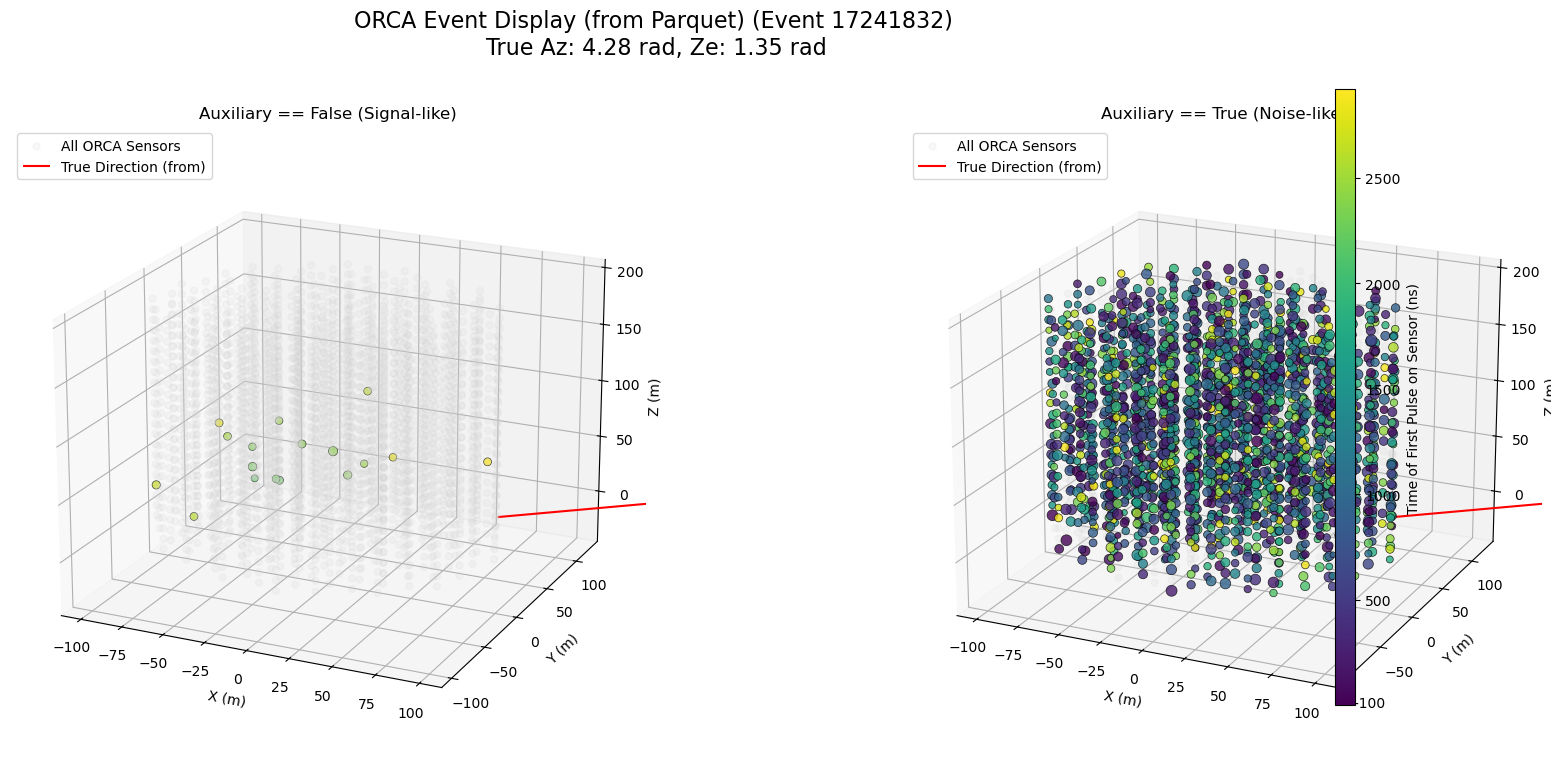

In [29]:

# 1. Define file paths (these should be accessible from your notebook)
ORCA_BASE_PATH = Path("/groups/pheno/inar/orca_prometheus")
GEOMETRY_FILE_ORCA = ORCA_BASE_PATH / "orca_sensor_geometry.csv" # Assumes it has sensor_id,x,y,z
PULSE_FILE_EXAMPLE = ORCA_BASE_PATH / "pulses/pulses_806.parquet"
TRUTH_FILE_EXAMPLE = ORCA_BASE_PATH / "mc_truth/mc_truth_806.parquet"
EVENT_NO_TO_DISPLAY = 17241832 # Example event ID from your screenshot

# 2. Load ORCA Sensor Geometry (ensure 'sensor_id' is the index or a column)
try:
    sensor_geometry_df_orca = pd.read_csv(GEOMETRY_FILE_ORCA)
    if 'sensor_id' not in sensor_geometry_df_orca.columns:
        print("Assuming row number is 0-indexed sensor_id for geometry.")
        sensor_geometry_df_orca['sensor_id'] = sensor_geometry_df_orca.index
    sensor_geometry_df_orca = sensor_geometry_df_orca.set_index('sensor_id', drop=False) # Ensure it's indexed
except FileNotFoundError:
    print(f"ERROR: ORCA geometry file not found at {GEOMETRY_FILE_ORCA}")
    # exit() # or handle error appropriately in notebook

# 3. Initialize SensorMapper
# For display, Z-offset calibration might not be critical, or you can enable it.
# If enabling, ensure the PULSE_FILE_EXAMPLE is representative.
sensor_mapper_orca = SensorMapping(str(GEOMETRY_FILE_ORCA))
sensor_mapper_orca.initialize_mapping(pulse_data_file_path=str(PULSE_FILE_EXAMPLE), apply_z_offset_calibration=True) # Or False

# 4. Load specific event data from Parquet
event_pulses, event_truth = load_event_from_parquet(
    EVENT_NO_TO_DISPLAY,
    str(PULSE_FILE_EXAMPLE),
    str(TRUTH_FILE_EXAMPLE),
    labels_to_extract=['initial_state_azimuth', 'initial_state_zenith'] # Add more if needed
)

# 5. Process for display
if event_pulses is not None:
    hit_data_aux_false_raw, hit_data_aux_true_raw = process_event_for_display_from_raw(
        event_pulses,
        sensor_mapper_orca,
        sensor_geometry_df_orca # Pass the geometry DF indexed by sensor_id
    )

    truth_direction_for_plot = None
    if event_truth and 'initial_state_azimuth' in event_truth and 'initial_state_zenith' in event_truth:
        truth_direction_for_plot = (event_truth['initial_state_azimuth'], event_truth['initial_state_zenith'])

    # 6. Plot
    plot_event_display(
        all_sensor_coords_df=sensor_geometry_df_orca,
        hit_data_aux_false=hit_data_aux_false_raw,
        hit_data_aux_true=hit_data_aux_true_raw,
        truth_direction_rad=truth_direction_for_plot,
        event_id_str=f"Event {EVENT_NO_TO_DISPLAY}",
        output_filename=f"orca_event_{EVENT_NO_TO_DISPLAY}_display_from_parquet.png",
        empty_dom_size=25 # Example: make empty DOMs larger
    )
else:
    print(f"Could not load data for event {EVENT_NO_TO_DISPLAY}")

